# Alpha Research Pipeline

7-step template: Signal -> Rank -> Position -> Shift -> Returns -> Combine -> Evaluate

Uses `data_loader.py` and `alpha_utils.py` — no logic lives in this notebook.
This notebook is just: load data -> define signal -> call `evaluate_alpha()` -> plot.

In [1]:
import matplotlib.pyplot as plt
from data_loader import load_data, get_close_prices, get_volume
from alpha_utils import evaluate_alpha
from alpha_utils import ts_rank
from alpha_utils import rolling_corr

data = load_data()
close = get_close_prices(data)
volume = get_volume(data)
n_stocks = close.shape[1]
print(close.shape)

Loading cached data from data/sp500_5y.parquet
(1255, 503)


## Alpha 1 — 21-day momentum

In [2]:
signal_alpha1 = close.pct_change(21, fill_method=None)
results_1 = evaluate_alpha(signal_alpha1, close, n_stocks)

print("Sharpe:", results_1["sharpe"])
print("IC mean:", results_1["ic_mean"])
print("ICIR:", results_1["icir"])

Sharpe: -0.10054801406387627
IC mean: -0.006177787063267017
ICIR: -0.030536156319343456


## Alpha 2 — Volume-weighted price trend

In [3]:
price_trend = close.pct_change(21, fill_method=None)
vol_weight = volume.rolling(21).mean()
signal_alpha2 = price_trend * vol_weight

results_2 = evaluate_alpha(signal_alpha2, close, n_stocks)

print("Sharpe:", results_2["sharpe"])
print("IC mean:", results_2["ic_mean"])
print("ICIR:", results_2["icir"])

Sharpe: 0.1775904676405182
IC mean: -0.00538666960354889
ICIR: -0.029074522629863705


## Rolling IC plot — Alpha 1

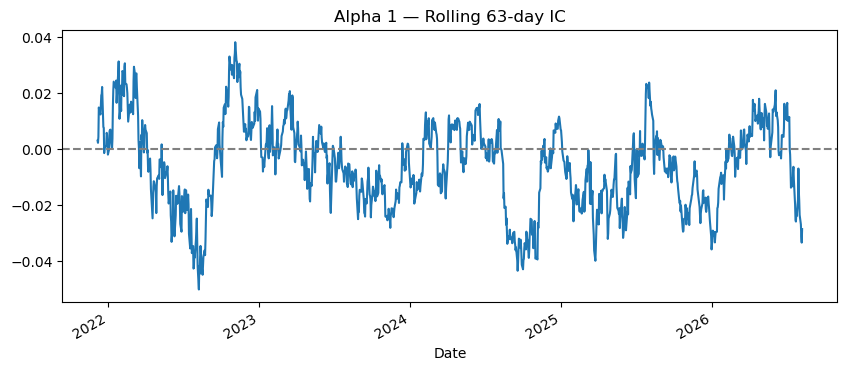

In [4]:
results_1["ic_series"].rolling(63).mean().plot(figsize=(10, 4), title="Alpha 1 — Rolling 63-day IC")
plt.axhline(0, color="grey", linestyle="--")
plt.show()

## Aplha 3

In [5]:
open_prices = data.xs('Open', axis=1, level='Price')

In [6]:
rank_open = open_prices.rank(axis=1)
rank_volume = volume.rank(axis=1)
roll_corr = rank_open.rolling(10).corr(rank_volume)
signal_alpha3 = -1 * (roll_corr)

In [7]:
results_3 = evaluate_alpha(signal_alpha3, close, n_stocks)

print('Sharpe:', results_3['sharpe'])
print('IC mean', results_3['ic_mean'])
print('ICIR', results_3['icir']) 

Sharpe: 0.22412629089611272
IC mean 0.002694015931150158
ICIR 0.04199867160359809


## Alpha 4

In [8]:
low_prices = data.xs('Low', axis=1, level='Price')

In [10]:
rank_low = low_prices.rank(axis=1)
ts_rank_low = ts_rank(rank_low, 9)
signal_alpha_4 = -1 * ts_rank_low

In [11]:
results_4 = evaluate_alpha(signal_alpha_4, close, n_stocks)
print('Sharpe:', results_4['sharpe'])
print('IC mean', results_4['ic_mean'])
print('ICIR', results_4['icir'])

Sharpe: 0.5890015063792607
IC mean 0.010448494449174827
ICIR 0.06237574512406685


## Rolling IC Plot Aplha 4

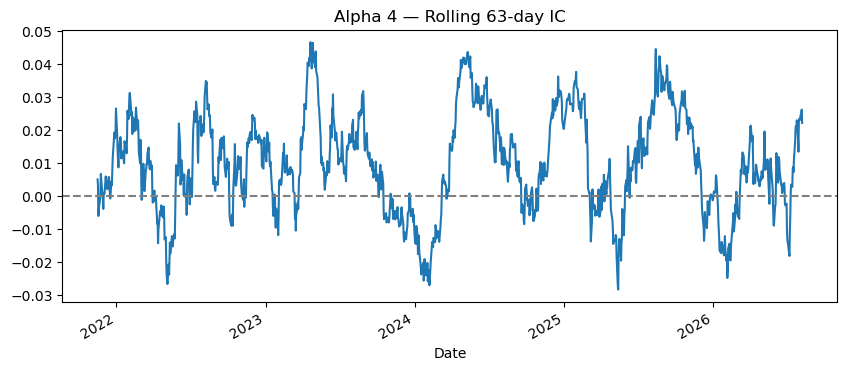

In [12]:
results_4['ic_series'].rolling(63).mean().plot(figsize=(10, 4), title='Alpha 4 — Rolling 63-day IC')
plt.axhline(0, color="grey", linestyle="--")
plt.show()

## Alpha 5

In [13]:
volume = data.xs("Volume", axis=1, level='Price')

In [14]:
signal_alpha5 = -1 * rolling_corr(open_prices, volume, 10)

In [16]:
results_5 = evaluate_alpha(signal_alpha5, close, n_stocks)

print('Sharpe:', results_5['sharpe'])
print('IC mean', results_5['ic_mean'])
print('ICIR', results_5['icir'])

Sharpe: 0.029584935399746083
IC mean 0.000843148185622812
ICIR 0.007474413117606575


## Rolling IC Plot Aplha 5

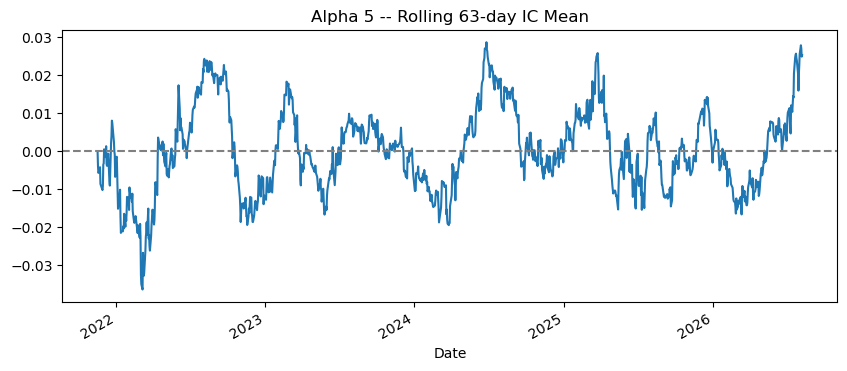

In [17]:
results_5['ic_series'].rolling(63).mean().plot(figsize=(10,4), title='Alpha 5 -- Rolling 63-day IC Mean')
plt.axhline(0, color="grey", linestyle="--")
plt.show()